# Проект 16 спринта

### Расчет MDE относительно n

In [1]:
import pandas as pd
from scipy.stats import t

# Загружаем данные
orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_orders.csv')
orders['order_time'] = pd.to_datetime(orders['order_time'])

# Параметры для расчёта 
alpha = 0.05 / 3 # уровень значимости
beta = 0.2 # вероятность ошибки II рода
group_count = 3 # количество групп
rollout_share = 50 # % трафика на эксперимент (нужно изменять и смотреть на результат)

# Зададим названия столбцов для числителя и знаменателя
unit_name = 'user_id'
numerator = 'completed_orders'
denominator = 'total_orders'

# Предпериод
start_date = pd.Timestamp('2024-09-23 00:00:00')
end_date = pd.Timestamp('2024-10-06 23:59:59')

# Фильтрация и агрегация данных
data_exp_orders = orders[
   (orders['order_time'] >= start_date) &
   (orders['order_time'] <= end_date) &
   (orders['status'] != 'cancelled_order_by_driver')]
completed_orders = data_exp_orders[data_exp_orders['status'] == 'completed'].groupby('user_id')[
   'order_id'].nunique().reset_index()
completed_orders = completed_orders.rename(columns={'order_id': 'completed_orders'})
total_orders = data_exp_orders.groupby('user_id')['order_id'].nunique().reset_index()
total_orders = total_orders.rename(columns={'order_id': 'total_orders'})
df_merged = pd.merge(completed_orders, total_orders, how='outer', on='user_id')
df_merged.fillna(0, inplace=True)

# Расчёт глобального значения метрики
global_ratio = df_merged[numerator].sum() / df_merged[denominator].sum()

# Линеаризация
df_merged['linearized_metric'] = df_merged[numerator] - global_ratio * df_merged[denominator]

# Размер выборки
n_total = len(df_merged) * (rollout_share / 100)
n = n_total / group_count
degrees_of_freedom = n_total - group_count

# Статистики по линеаризованной метрике
std = df_merged['linearized_metric'].std()
mean = df_merged['linearized_metric'].mean()

# Критические значения t-распределения
t_alpha = t.ppf(1 - alpha / 2, degrees_of_freedom)
t_beta = t.ppf(1 - beta, degrees_of_freedom)

# Расчет MDE
left_factor = (t_alpha + t_beta) ** 2
right_factor = 2 * (std ** 2) / n
MDE_lin = (left_factor * right_factor) ** 0.5

# Преобразуем к ratio-метрике
abs_mde = MDE_lin / df_merged[denominator].mean()
rel_mde = ((abs_mde / global_ratio) * 100).round(2)

# Вывод
print(f"Абсолютный MDE метрики-отношения: {abs_mde}")
print(f"Относительный MDE метрики-отношения, в %: {rel_mde}%")

Абсолютный MDE метрики-отношения: 0.03190946277870488
Относительный MDE метрики-отношения, в %: 3.65%


### Убираем пользователей попавших в 2 группы

In [2]:
import pandas as pd

split_data = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_split_data.csv')

split_data['time'] = pd.to_datetime(split_data['time'])

# Считаем кол-во уникальных групп на user_id
flawed_users = split_data.groupby('user_id')['group_name'].nunique().reset_index()

# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group_name'] > 1]

# Убираем пользователей, попавших в несколько групп
split_data_correct = split_data[~split_data['user_id'].isin(flawed_users['user_id'])]

print('Данные очищены')
split_data_correct.head()

Данные очищены


,user_id,time,group_name
0,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:00,treatment_2
1,6640de09-bbb9-4a85-ab91-2b6c032da764,2024-10-14 00:01:53,treatment_1
2,f2666461-054d-4aeb-b9a4-c9a5477da043,2024-10-14 00:05:34,treatment_2
3,0d3faf2d-4da9-47dc-bdba-c29dc3863b5d,2024-10-14 00:05:48,control
4,180e1d77-818f-4c29-87bf-f86b52249359,2024-10-14 00:13:31,treatment_2


### Подготовка даннных

In [3]:
import pandas as pd
from IPython.display import display
# Настройки отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

# Загрузка данных
orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_orders.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_events.csv')
split_data_correct = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_split_data_correct.csv')

# Преобразование времени
orders['order_time'] = pd.to_datetime(orders['order_time'])
events['time'] = pd.to_datetime(events['time'])
split_data_correct['time'] = pd.to_datetime(split_data_correct['time'])

# Указываем переменные начала и конца экспериментального периода
start_date = pd.Timestamp('2024-10-14 00:00:00')
end_date = pd.Timestamp('2024-10-27 23:59:59')

# Фильтруем датасет по датам и статусу заказа
data_exp_orders = orders[(orders['order_time'].between(start_date, end_date)) & (orders['status']!='cancelled_by_driver')]

# Фильтруем датасет по датам
data_exp_events = events[events['time'].between(start_date, end_date)]

# Объединение таблицы с событиями с данными о группах
data_exp_orders = pd.merge(data_exp_orders, split_data_correct[['user_id', 'group_name']], on='user_id', how='inner')
# Объединение таблицы с событиями с данными о группах
data_exp_events = pd.merge(data_exp_events, split_data_correct[['user_id', 'group_name']], on='user_id', how='inner' )

display(data_exp_orders.head(5))
display(data_exp_events.head(5))

,index,user_id,order_id,order_time,ride_start_time,ride_finish_time,status,paid_amt,payment_type,group_name
0,14,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a4e8f585-6963-4de7-9c0d-85631cd0aec3,2024-10-23 02:58:57,2024-10-23 03:05:47.240,2024-10-23 03:41:41,completed,1025,card,control
1,15,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a42ca294-1daf-4abb-8781-16c957cb7336,2024-10-23 07:54:28,2024-10-23 07:59:55.960,2024-10-23 08:24:50,completed,364,card,control
2,16,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a6d71fde-efb8-4087-ba44-1a6c0b164337,2024-10-27 12:03:40,2024-10-27 12:09:47.400,2024-10-27 12:31:30,completed,640,card,control
3,100,001c57aa-e1f1-40bf-9d79-8e064ee03891,736e2057-2e58-4eb6-82ca-12615e7fa533,2024-10-22 08:05:39,2024-10-22 08:12:56.760,2024-10-22 08:36:03,completed,304,card,control
4,182,0031962e-772a-48c3-85dc-76c3d250e24f,18425573-2c3c-497c-9d03-c4334954a668,2024-10-14 17:56:46,2024-10-14 18:00:58.330,2024-10-14 18:29:07,completed,647,card,control


,index,user_id,time,session_id,event_name,group_name
0,1514428,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:00,253314,app_start,treatment_2
1,1514429,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:04,253314,order_initiate,treatment_2
2,1514430,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:00:19,253314,order_create,treatment_2
3,1514431,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 00:17:09,253314,order_cancel,treatment_2
4,1514432,43a5b22e-6fed-4c22-9855-82d3304b3031,2024-10-14 04:28:47,122952,app_start,treatment_2


Кумулятивное значение ключевой метрики

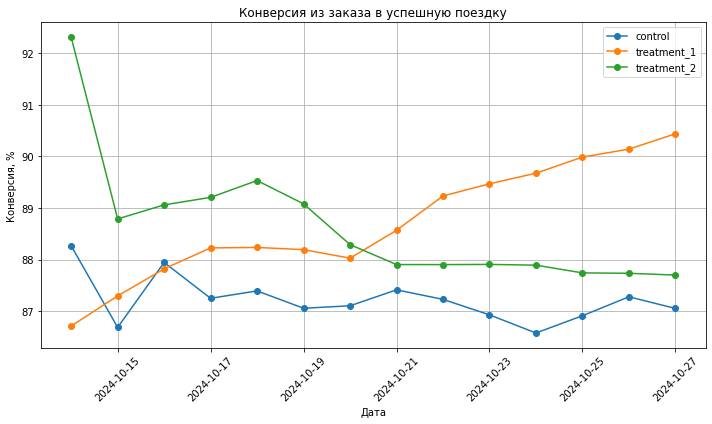

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка и подготовка данных
data_exp_orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_data_exp_orders.csv')
data_exp_orders['order_time'] = pd.to_datetime(data_exp_orders['order_time'])

# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

# Конверсия из создания заказа в успешную поездку
for current_date in date_list:
   # Заказы до текущей даты включительно
   orders_to_date = data_exp_orders[data_exp_orders['order_time'].dt.date <= current_date]
   # Фильтрация по статусу
   completed_orders_to_date = orders_to_date[orders_to_date['status']=='completed']

   # Общее количество заказов в каждой группе, столбец с расчётом должен называться total_orders
   total_orders_by_group = orders_to_date.groupby('group_name')['order_id'].nunique().reset_index()
   # Переименование столбца
   total_orders_by_group = total_orders_by_group.rename(columns={'order_id': 'total_orders'})

   # Общее количество завершённых заказов в каждой группе, столбец с расчётом должен называться completed_orders
   completed_orders_by_group = completed_orders_to_date.groupby('group_name')['order_id'].nunique().reset_index() 
    
   # Переименование столбца
   completed_orders_by_group = completed_orders_by_group.rename(columns={'order_id': 'completed_orders'})

   # Объединение и расчёт конверсии
   df_merged_orders = total_orders_by_group.merge(completed_orders_by_group, on='group_name')
   df_merged_orders['conversion'] = df_merged_orders['completed_orders'] /  df_merged_orders['total_orders'] * 100

   df_merged_orders['date'] = current_date
   records.append(df_merged_orders)

# Собираем всё в итоговый датафрейм
conversion_df = pd.concat(records, ignore_index=True)

# Строим график
plt.figure(figsize=(10, 6))
for group in conversion_df['group_name'].unique():
    group_data = conversion_df[conversion_df['group_name']==group]
    plt.plot(group_data['date'], group_data['conversion'], marker='o', label=group)
plt.title('Конверсия из заказа в успешную поездку')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Кумулятивное значение барьерной метрики

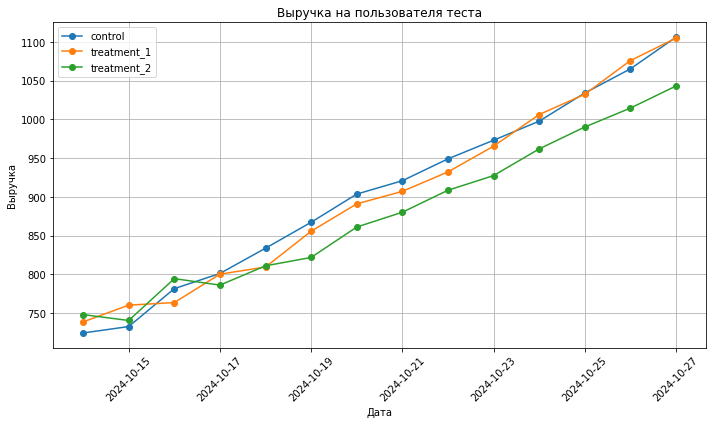

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка и подготовка данных
data_exp_orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_data_exp_orders.csv')
data_exp_orders['order_time'] = pd.to_datetime(data_exp_orders['order_time'])

# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

# Выручка на пользователя теста
for current_date in date_list:
   # Выполненные заказы до текущей даты включительно
   completed_orders_to_date = data_exp_orders[data_exp_orders['order_time'].dt.date <= current_date]
   # Фильтрация по статусу
   completed_orders_to_date = completed_orders_to_date[completed_orders_to_date['status']=='completed']

   # Суммарная выручка по группам
   summa_by_group = completed_orders_to_date.groupby('group_name')['paid_amt'].sum().reset_index()
   # Переименование столбца
   summa_by_group = summa_by_group.rename(columns={'paid_amt': 'revenue_total'})

   # Количество уникальных пользователей, совершивших заказ, по группам
   users_by_group = completed_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
   # Переименование столбца
   users_by_group = users_by_group.rename(columns={'user_id': 'users_total'})

   # Объединение и расчёт выручки на пользователя
   df_merged_orders = summa_by_group.merge(users_by_group, on='group_name')
   df_merged_orders['revenue_per_user'] = df_merged_orders['revenue_total'] / df_merged_orders['users_total']

   df_merged_orders['date'] = current_date
   records.append(df_merged_orders)

# Собираем в итоговый датафрейм
revenue_df = pd.concat(records)
revenue_df
# Строим график
plt.figure(figsize=(10, 6))

for group in revenue_df['group_name'].unique():
    group_data = revenue_df[revenue_df['group_name']==group]
    plt.plot(group_data['date'], group_data['revenue_per_user'], marker='o', label=group)

plt.title('Выручка на пользователя теста')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
display(data_exp_orders.head())

,index,user_id,order_id,order_time,ride_start_time,ride_finish_time,status,paid_amt,payment_type,group_name
0,14,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a4e8f585-6963-4de7-9c0d-85631cd0aec3,2024-10-23 02:58:57,2024-10-23 03:05:47.240,2024-10-23 03:41:41,completed,1025,card,control
1,15,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a42ca294-1daf-4abb-8781-16c957cb7336,2024-10-23 07:54:28,2024-10-23 07:59:55.960,2024-10-23 08:24:50,completed,364,card,control
2,16,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a6d71fde-efb8-4087-ba44-1a6c0b164337,2024-10-27 12:03:40,2024-10-27 12:09:47.400,2024-10-27 12:31:30,completed,640,card,control
3,100,001c57aa-e1f1-40bf-9d79-8e064ee03891,736e2057-2e58-4eb6-82ca-12615e7fa533,2024-10-22 08:05:39,2024-10-22 08:12:56.760,2024-10-22 08:36:03,completed,304,card,control
4,182,0031962e-772a-48c3-85dc-76c3d250e24f,18425573-2c3c-497c-9d03-c4334954a668,2024-10-14 17:56:46,2024-10-14 18:00:58.330,2024-10-14 18:29:07,completed,647,card,control


In [7]:
import pandas as pd
from scipy.stats import ttest_ind

# Настройки отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

# Загрузка данных
data_exp_orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_data_exp_orders.csv')
data_exp_orders['order_time'] = pd.to_datetime(data_exp_orders['order_time'])

# Расчитываем числитель и знаменатель метрики через группировку и лямбду
df_test = data_exp_orders.groupby(['group_name', 'user_id']).agg(
   total_rides=('order_id', 'nunique'),
   successful_rides=('status', lambda x: x.eq('completed').sum())
).reset_index()

# Получаем список всех уникальных групп с сортировкой
groups = sorted(df_test.group_name.unique())

# Создаём словарь для хранения данных по группам
group_data = {}
for group in groups:
    group_data[group] = df_test[df_test['group_name'] == group]

    
# group_data    
# Создаём список для хранения результатов
results = []

# Проводим попарные сравнения всех групп
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
               
        data1 = group_data[group1]
        data2 = group_data[group2]
               
        # Расчет метрик
        ratio = data1['successful_rides'].sum() / data1['total_rides'].sum()
               
        lin_metric1 = data1['successful_rides'] - ratio * data1['total_rides']
        lin_metric2 = data2['successful_rides'] - ratio * data2['total_rides']


        # Статистический тест
        _, p_value = ttest_ind(lin_metric1, lin_metric2, equal_var=False)

        # Расчет метрик
        mean1 = data1['successful_rides'].sum() / data1['total_rides'].sum()
        mean2 = data2['successful_rides'].sum() / data2['total_rides'].sum()


        # Добавление результатов
        results.append({
            'Group A': group1,
            'Group B': group2,
            'p-value': p_value,
            'Mean A': mean1,
            'Mean B': mean2,
            'Absolute Lift':mean2 - mean1 ,
            'Relative Lift (%)': (mean2 - mean1) / mean1 * 100 
        })

# Создаём DataFrame из результатов
results_df = pd.DataFrame(results)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df)

Результаты сравнения групп:
       Group A      Group B   p-value    Mean A    Mean B  Absolute Lift  Relative Lift (%)
0      control  treatment_1  0.000184  0.870543  0.904366       0.033823           3.885230
1      control  treatment_2  0.516518  0.870543  0.877003       0.006460           0.742035
2  treatment_1  treatment_2  0.003382  0.904366  0.877003      -0.027363          -3.025642


### Задание 2. Итоги теста. Вспомогательная метрика 1
Рассчитайте и визуализируйте кумулятивные значения вспомогательной метрики — конверсии из просмотра формы в создание заказа. 

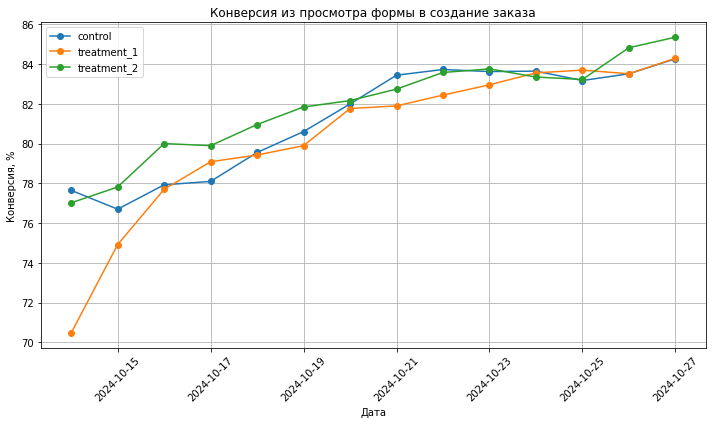

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data_exp_events = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_data_exp_events.csv')
data_exp_events['time'] = pd.to_datetime(data_exp_events['time'])

# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_events['time'].dt.date.unique()
date_list.sort()

# Конверсия из просмотра формы в создание заказа
for current_date in date_list:
   # События до текущей даты включительно
   events_to_date = data_exp_events[data_exp_events['time'].dt.date <= current_date]
   # Фильтруем order_initiate
   initiated_orders_to_date = events_to_date[events_to_date['event_name']=='order_initiate']
   # Фильтруем order_create
   created_orders_to_date = events_to_date[events_to_date['event_name']=='order_create']

   # Общее количество пользователей, которые открыли форму заказа, в каждой группе. Столбец с расчётом назовите users_initiated
   initiated_users_by_group = initiated_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
   # Переименовываем столбец
   initiated_users_by_group = initiated_users_by_group.rename(columns={'user_id': 'users_initiated'})

   # Количество пользователей, которые создали заказ, в каждой группе. Столбец с расчётом назовите users_created
   created_users_by_group = created_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
   # Переименовываем столбец
   created_users_by_group = created_users_by_group.rename(columns={'user_id': 'users_created'})

   # Объединение и расчёт конверсии
   df_merged_events = initiated_users_by_group.merge(created_users_by_group, on='group_name')
   df_merged_events['conversion'] = 100 * df_merged_events['users_created'] / df_merged_events['users_initiated']

   df_merged_events['date'] = current_date
   records.append(df_merged_events)


# Собираем в итоговый датафрейм
conversion_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10, 6))
for group in conversion_df['group_name'].unique():
    group_data = conversion_df[conversion_df['group_name']==group]
    plt.plot(group_data['date'], group_data['conversion'], marker='o', label=group)
plt.title('Конверсия из просмотра формы в создание заказа')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
data_exp_orders.head()

,index,user_id,order_id,order_time,ride_start_time,ride_finish_time,status,paid_amt,payment_type,group_name
0,14,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a4e8f585-6963-4de7-9c0d-85631cd0aec3,2024-10-23 02:58:57,2024-10-23 03:05:47.240,2024-10-23 03:41:41,completed,1025,card,control
1,15,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a42ca294-1daf-4abb-8781-16c957cb7336,2024-10-23 07:54:28,2024-10-23 07:59:55.960,2024-10-23 08:24:50,completed,364,card,control
2,16,00019148-3158-4ebe-aae0-25cd0e1b1b8a,a6d71fde-efb8-4087-ba44-1a6c0b164337,2024-10-27 12:03:40,2024-10-27 12:09:47.400,2024-10-27 12:31:30,completed,640,card,control
3,100,001c57aa-e1f1-40bf-9d79-8e064ee03891,736e2057-2e58-4eb6-82ca-12615e7fa533,2024-10-22 08:05:39,2024-10-22 08:12:56.760,2024-10-22 08:36:03,completed,304,card,control
4,182,0031962e-772a-48c3-85dc-76c3d250e24f,18425573-2c3c-497c-9d03-c4334954a668,2024-10-14 17:56:46,2024-10-14 18:00:58.330,2024-10-14 18:29:07,completed,647,card,control


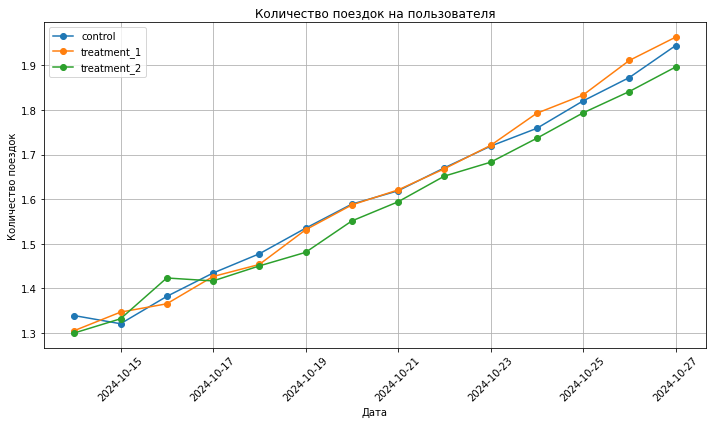

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

data_exp_orders = pd.read_csv('https://code.s3.yandex.net/datasets/PA_5_10_1_data_exp_orders.csv')
data_exp_orders['order_time'] = pd.to_datetime(data_exp_orders['order_time'])

# Пустой список для результатов
records = []

# Формируем лист дат для цикла и сортируем его
date_list = data_exp_orders['order_time'].dt.date.unique()
date_list.sort()

# Конверсия из просмотра формы в создание заказа
for current_date in date_list:
   # Выполненные заказы до текущей даты включительно
   completed_orders_to_date = data_exp_orders[data_exp_orders['order_time'].dt.date <= current_date]
   # Фильтрация по статусу
   completed_orders_to_date = completed_orders_to_date[completed_orders_to_date['status'] == 'completed']

   # Количество заказов (поездок) всего. Столбец с расчётом — orders_total
   orders_by_group = completed_orders_to_date.groupby('group_name')['order_id'].nunique().reset_index()
   # Переименовать столбец
   orders_by_group = orders_by_group.rename(columns={'order_id': 'orders_total'})

   # Количество уникальных пользователей, совершивших заказ, по группам. Столбец с расчётом — users_total
   users_by_group = completed_orders_to_date.groupby('group_name')['user_id'].nunique().reset_index()
   # Переименовать столбец
   users_by_group = users_by_group.rename(columns={'user_id': 'users_total'})

   # Объединение и расчёт количества поездок на пользователя
   df_merged_orders = pd.merge(orders_by_group, users_by_group, how='outer', on='group_name')

   df_merged_orders['trips_per_user_to_date'] = df_merged_orders['orders_total'] / df_merged_orders['users_total']

   df_merged_orders['date'] = current_date
   records.append(df_merged_orders)

# Собираем в итоговый датафрейм
trips_number_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10, 6))

for group in trips_number_df['group_name'].unique():
   group_data = trips_number_df[trips_number_df['group_name'] == group]
   plt.plot(group_data['date'], group_data['trips_per_user_to_date'], marker='o', label=group)

plt.title('Количество поездок на пользователя')
plt.xlabel('Дата')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()